# 05 · Feature Engineering
### The Outliers · Mumbai Rent Radar

The diagnostics were blunt: the flat's own features carry the price, amenity counts do not.
So feature engineering has two jobs — (1) squeeze more signal out of the physical features,
and (2) turn *location* into a number the model can use, since raw metro/school counts fail.

We work through it in four moves: **derive** new features, **select** by correlation,
**normalise** (and justify the method), and **encode** categories.

**Input:** `data/processed/listings_imputed.csv` + attributes → **Output:** `data/processed/listings_features.csv`

In [2]:
import sys, warnings
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
import style
warnings.filterwarnings("ignore")
style.setup()

df = pd.read_csv("../data/processed/listings_imputed.csv")
att = pd.read_csv("../data/processed/locality_attributes.csv")
m = df.merge(att, on="locality_name", how="left", suffixes=("", "_a"))
m["zone"] = m["zone"].fillna("unknown")

## 1 · Derive new features
Each new column encodes a piece of domain sense a raw column cannot.

In [3]:
# winsorise rent-per-sqft at IQR fences (decision from diagnostics) before deriving
m["rent_per_sqft"] = m["rent"] / m["size"]
q1, q3 = m["rent_per_sqft"].quantile([0.25, 0.75]); iqr = q3 - q1
lo, hi = max(q1 - 1.5 * iqr, 0), q3 + 1.5 * iqr
m["rent_per_sqft"] = m["rent_per_sqft"].clip(lo, hi)

m["log_rent"] = np.log(m["rent"])                       # target
m["size_per_bhk"] = m["size"] / m["bhk"]                # avg room size — roominess
m["bath_per_bhk"] = m["bathroom"] / m["bhk"]            # bathroom generosity
m["floor_ratio"] = np.where(m["total_floors"] > 0, m["floor_num"] / m["total_floors"], 0)  # relative height
m["is_tall_building"] = (m["total_floors"] >= 20).astype(int)
m["floor_band"] = pd.cut(m["floor_num"], [-9, 0, 3, 10, 100],
                         labels=["ground/basement", "low (1-3)", "mid (4-10)", "high (11+)"])
# location-as-a-number: how pricey is this locality on average (leak-safe version fit in modelling)
loc_level = m.groupby("locality_name")["log_rent"].transform("mean")
m["locality_price_level"] = loc_level
print("New features added:", ["size_per_bhk", "bath_per_bhk", "floor_ratio",
      "is_tall_building", "floor_band", "rent_per_sqft", "locality_price_level"])
m[["size_per_bhk", "bath_per_bhk", "floor_ratio", "locality_price_level"]].describe().round(2)

New features added: ['size_per_bhk', 'bath_per_bhk', 'floor_ratio', 'is_tall_building', 'floor_band', 'rent_per_sqft', 'locality_price_level']


,size_per_bhk,bath_per_bhk,floor_ratio,locality_price_level
count,5000.00,5000.00,5000.00,5000.00
mean,433.54,1.09,0.51,10.98
std,188.65,0.36,0.27,0.26
min,150.00,0.50,-0.14,9.10
25%,350.00,1.00,0.32,10.85
50%,411.00,1.00,0.52,10.98
75%,488.00,1.00,0.71,11.13
max,7500.00,4.00,1.00,12.54


## 2 · Correlation-based feature engineering
We keep features that **correlate with rent** and drop ones that merely **duplicate each
other**. First, how much signal each candidate carries.

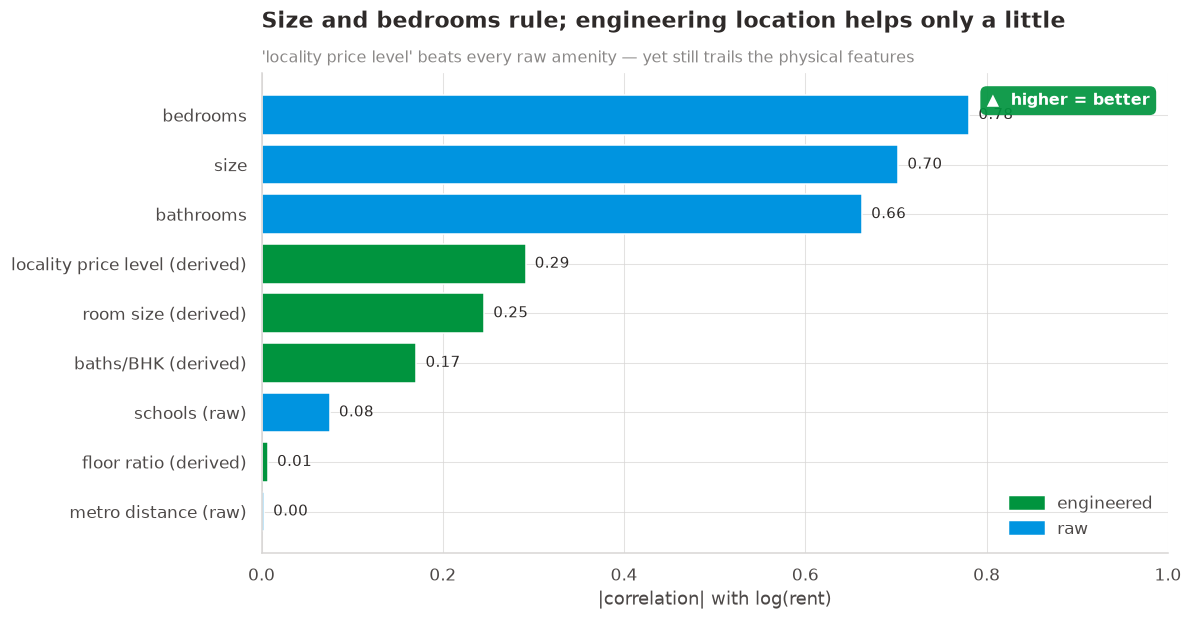

In [4]:
cands = {"bhk": "bedrooms", "size": "size", "bathroom": "bathrooms",
         "size_per_bhk": "room size (derived)", "bath_per_bhk": "baths/BHK (derived)",
         "floor_ratio": "floor ratio (derived)", "locality_price_level": "locality price level (derived)",
         "nearest_metro_km": "metro distance (raw)", "school_count_2km": "schools (raw)"}
cc = m[list(cands)].assign(y=m["log_rent"]).corr()["y"].drop("y").abs().sort_values()
is_deriv = ["derived" in cands[i] for i in cc.index]
colors = [style.GREEN if d else style.BLUE for d in is_deriv]
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.barh([cands[i] for i in cc.index], cc.values, color=colors)
for i, v in enumerate(cc.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10, color=style.INK)
ax.set_xlim(0, 1); ax.set_xlabel("|correlation| with log(rent)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=style.GREEN, label="engineered"), Patch(color=style.BLUE, label="raw")],
          loc="lower right")
style.title(ax, "Size and bedrooms rule; engineering location helps only a little",
            "'locality price level' beats every raw amenity — yet still trails the physical features")
style.direction_badge(ax, "higher", "upper right")
fig.tight_layout(); style.save(fig, "05_feature_correlation"); plt.show()

**Insight:** the derived **locality price level** (~0.29) is the best *location* signal we can
build — it beats every raw amenity (schools 0.08, metro 0.00) — but it still sits far below
the flat's own **size, bedrooms and bathrooms**. Location matters, just far less than a
location-obsessed city assumes. **Decision:** keep it, computed leak-safely (train-fold means)
in the modelling notebook, but expect the physical features to carry the model.

### Prune redundant features (multicollinearity)
`size`, `bhk`, `bathroom` move together — feeding all three to a linear model inflates
variance. We check VIF and keep the most informative of each cluster.

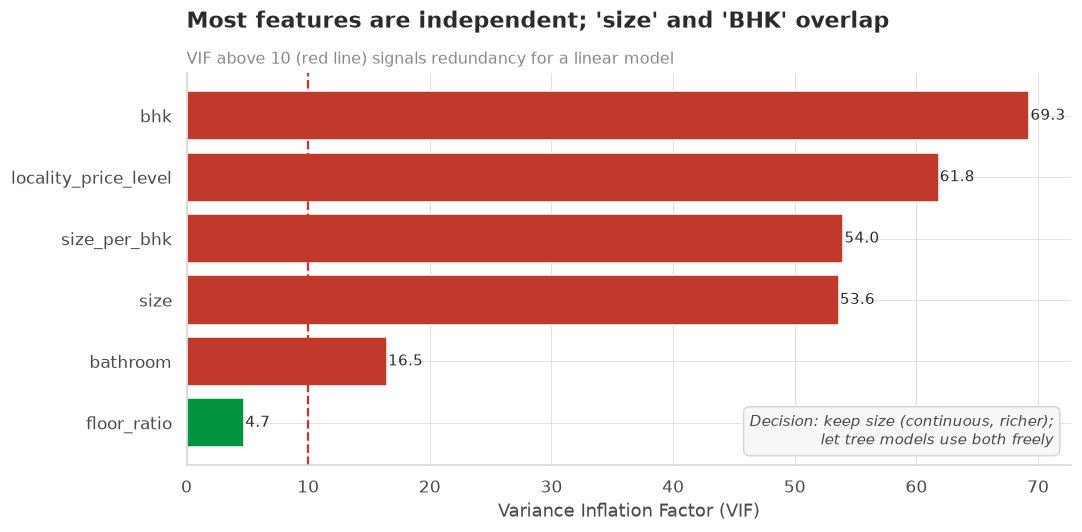

In [5]:
vif_cols = ["bhk", "size", "bathroom", "size_per_bhk", "floor_ratio", "locality_price_level"]
X = m[vif_cols].fillna(m[vif_cols].median())
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                index=vif_cols).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = [style.BAD if v > 10 else style.GREEN for v in vif.values]
ax.barh(vif.index, vif.values, color=colors)
for i, v in enumerate(vif.values):
    ax.text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=10, color=style.INK)
ax.axvline(10, color=style.BAD, ls="--", lw=1.5)
ax.set_xlabel("Variance Inflation Factor (VIF)")
style.title(ax, "Most features are independent; 'size' and 'BHK' overlap",
            "VIF above 10 (red line) signals redundancy for a linear model")
style.note(ax, "Decision: keep size (continuous, richer);\nlet tree models use both freely", where="lower right")
fig.tight_layout(); style.save(fig, "05_vif"); plt.show()

## 3 · Normalisation — explore, then choose
Linear and regularised models need features on a comparable scale. Skewed features
(like `size`) can break naive scaling, so we test four transforms and pick by which one
**behaves best under outliers**.

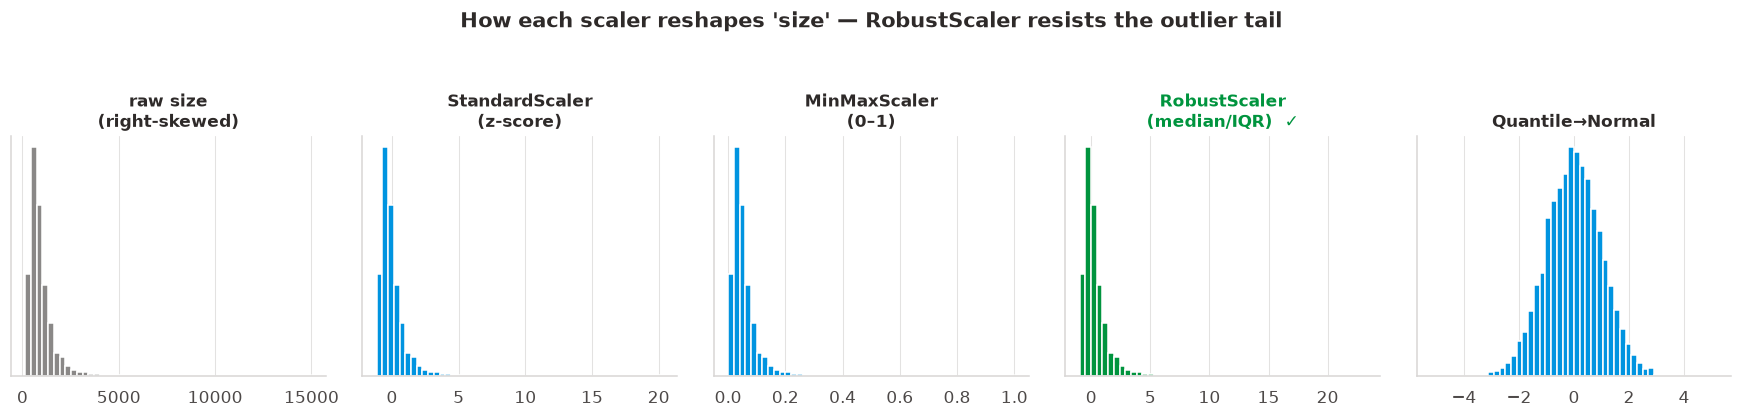

In [6]:
scalers = {"StandardScaler\n(z-score)": StandardScaler(),
           "MinMaxScaler\n(0–1)": MinMaxScaler(),
           "RobustScaler\n(median/IQR)": RobustScaler(),
           "Quantile→Normal": QuantileTransformer(output_distribution="normal", n_quantiles=500)}
raw_size = m[["size"]].values
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
axes[0].hist(raw_size, bins=50, color=style.GREY); axes[0].set_title("raw size\n(right-skewed)", fontsize=11)
for ax, (name, sc) in zip(axes[1:], scalers.items()):
    vals = sc.fit_transform(raw_size)
    ax.hist(vals, bins=50, color=style.BLUE if "Robust" not in name else style.GREEN)
    ax.set_title(name, fontsize=11)
for ax in axes: ax.set_yticks([]); ax.set_xlabel("")
axes[3].set_title("RobustScaler\n(median/IQR)  ✓", fontsize=11, color=style.GREEN, fontweight="bold")
fig.suptitle("How each scaler reshapes 'size' — RobustScaler resists the outlier tail",
             fontsize=14, fontweight="bold", color=style.INK, x=0.5, y=1.05, ha="center")
fig.tight_layout(); style.save(fig, "05_normalization"); plt.show()

**Insight:** MinMax squashes everything into a sliver because of extreme values;
StandardScaler is pulled by the tail; **RobustScaler** (centres on the median, scales by
IQR) stays stable; Quantile→Normal is powerful but distorts spacing. **Decision:** use
**RobustScaler** for linear/regularised models — it matches our winsorising philosophy and
ignores the typo tail. Tree models need no scaling and get the raw values.

## 4 · Encode categories & assemble the feature table
Low-cardinality categoricals → one-hot. High-cardinality locality → the numeric price
level we engineered. The final table keeps identity columns so modelling can encode safely.

In [7]:
feat = m[[
    "listing_id", "locality_name", "zone",
    # physical
    "bhk", "size", "bathroom", "floor_num", "total_floors",
    # engineered numeric
    "size_per_bhk", "bath_per_bhk", "floor_ratio", "is_tall_building",
    "rent_per_sqft", "locality_price_level",
    # categorical
    "area_type", "furnishing_status", "tenant_preferred", "point_of_contact", "floor_band",
    # target
    "rent", "log_rent",
]].copy()
feat.to_csv("../data/processed/listings_features.csv", index=False)
print("Saved listings_features.csv", feat.shape)
print("Model-ready feature columns:", [c for c in feat.columns if c not in
      ("listing_id", "locality_name", "rent", "log_rent")])

Saved listings_features.csv (5000, 21)
Model-ready feature columns: ['zone', 'bhk', 'size', 'bathroom', 'floor_num', 'total_floors', 'size_per_bhk', 'bath_per_bhk', 'floor_ratio', 'is_tall_building', 'rent_per_sqft', 'locality_price_level', 'area_type', 'furnishing_status', 'tenant_preferred', 'point_of_contact', 'floor_band']


### Feature-engineering takeaways
- **Location turned into a number** (`locality_price_level`) beats every raw amenity count,
  but stays a *minor* lever next to size and bedrooms — an honest, memory-consistent result.
- **Derived roominess features** (`size_per_bhk`, `bath_per_bhk`) add a little signal beyond raw counts.
- **RobustScaler** chosen after testing four transforms — it survives the outlier tail.
- **Redundancy checked** with VIF; trees keep everything, linear models keep the richer of
  each correlated pair.

Next: train several models on these features and let the best one win.